# OpenAI API Models Demo

This notebook demonstrates how to use the `OpenAIModel` class to extract next-token logits and probabilities from OpenAI's API, with a focus on **few-shot prompting for medical multiple-choice questions**.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

from src.models.api_models import OpenAIModel

## 1. Basic Usage - Initialize Model

The model will automatically use the `OPENAI_API_KEY` environment variable.

In [2]:
# Initialize the model
model = OpenAIModel(
    model_name="gpt-4o-mini",  # You can also use "gpt-4", "gpt-3.5-turbo", etc.
    top_logprobs=10,  # Get top 10 alternative tokens at each position
    temperature=1.0,
    max_tokens=50  # Limit response length
)

print(f"Model initialized: {model.model_name}")
print(f"Top logprobs to return: {model.top_logprobs}")

Model initialized: gpt-4o-mini
Top logprobs to return: 10


## 2. Few-Shot Prompting for Medical MCQs (MedQA/MedMCQA Style)

Demonstrate few-shot prompting to elicit single-character (A, B, C, D) responses, following the exact prompt format from `medqa_utils.py` and `medmcqa_utils.py`.

In [3]:
# Few-shot examples to teach the model the expected format
few_shot_examples = [
    {
        "question": "A 45-year-old man presents with fever and productive cough. Chest X-ray shows lobar consolidation. What is the most likely diagnosis?",
        "options": {
            "A": "Viral pneumonia",
            "B": "Bacterial pneumonia",
            "C": "Tuberculosis",
            "D": "Lung cancer"
        },
        "answer": "B"
    },
    {
        "question": "Which hormone is primarily responsible for regulating blood glucose levels?",
        "options": {
            "A": "Cortisol",
            "B": "Insulin",
            "C": "Thyroxine",
            "D": "Glucagon"
        },
        "answer": "B"
    },
    {
        "question": "What is the most common cause of hyperthyroidism?",
        "options": {
            "A": "Hashimoto's thyroiditis",
            "B": "Graves' disease",
            "C": "Toxic multinodular goiter",
            "D": "Thyroid adenoma"
        },
        "answer": "B"
    }
]

def create_few_shot_prompt(question, options, num_examples=2, prompt_type='default'):
    """
    Create a few-shot prompt for medical MCQ following MedQA/MedMCQA format.
    
    Args:
        question: The question text
        options: Dictionary with keys A, B, C, D (and optionally E) and option text
        num_examples: Number of few-shot examples to include
        prompt_type: 'default', 'COT', or 'Debiasing'
    """
    prompt = ""
    
    # Add prompt prefix based on type (from medqa_utils.py)
    if prompt_type == 'COT':
        prompt = "Let's think step by step:\n\n"
    elif prompt_type == 'Debiasing':
        prompt = "(Please note that the provided options have been randomly shuffled.)\n\n"
    
    # Add few-shot examples
    for i in range(min(num_examples, len(few_shot_examples))):
        example = few_shot_examples[i]
        prompt += f"Question: {example['question']}\n"
        for option_key in ['A', 'B', 'C', 'D', 'E']:
            if option_key in example['options']:
                prompt += f"{option_key}. {example['options'][option_key]}\n"
        prompt += f"Answer: {example['answer']}\n\n"
    
    # Add the actual question (following exact format from medqa_utils.py line 286-299)
    prompt += f"Question: {question}\n"
    for option_key in ['A', 'B', 'C', 'D', 'E']:
        if option_key in options:
            prompt += f"{option_key}. {options[option_key]}\n"
    prompt += "Answer:"
    
    return prompt

# Test question
test_question = {
    "question": "A 65-year-old patient presents with chest pain radiating to the left arm and diaphoresis. ECG shows ST-segment elevation in leads II, III, and aVF. What is the most likely diagnosis?",
    "options": {
        "A": "Gastroesophageal reflux disease",
        "B": "Inferior wall myocardial infarction",
        "C": "Costochondritis",
        "D": "Pulmonary embolism"
    }
}

# Create few-shot prompt
few_shot_prompt = create_few_shot_prompt(
    test_question['question'],
    test_question['options'],
    num_examples=2
)

print("Few-Shot Prompt (following MedQA/MedMCQA format):")
print("="*80)
print(few_shot_prompt)
print("="*80)

Few-Shot Prompt (following MedQA/MedMCQA format):
Question: A 45-year-old man presents with fever and productive cough. Chest X-ray shows lobar consolidation. What is the most likely diagnosis?
A. Viral pneumonia
B. Bacterial pneumonia
C. Tuberculosis
D. Lung cancer
Answer: B

Question: Which hormone is primarily responsible for regulating blood glucose levels?
A. Cortisol
B. Insulin
C. Thyroxine
D. Glucagon
Answer: B

Question: A 65-year-old patient presents with chest pain radiating to the left arm and diaphoresis. ECG shows ST-segment elevation in leads II, III, and aVF. What is the most likely diagnosis?
A. Gastroesophageal reflux disease
B. Inferior wall myocardial infarction
C. Costochondritis
D. Pulmonary embolism
Answer:


## 3. Extract Answer Choice Probabilities

Get the probabilities for each answer choice (A, B, C, D) from the first token.

In [4]:
# Use a model with lower temperature and max_tokens=1 for single-character response
model_few_shot = OpenAIModel(
    model_name="gpt-4o-mini",
    top_logprobs=20,  # Get more alternatives to ensure we capture all answer choices
    temperature=0.3,  # Lower temperature for more deterministic responses
    max_tokens=1  # Only generate single character
)

result = model_few_shot.get_next_token_logits(few_shot_prompt, return_full_distribution=True)

print(f"\nModel Response: '{result['generated_text']}'")
print(f"\n" + "="*80)
print("Analysis of first token generation (answer choice probabilities):")
print("="*80)

if result['top_logprobs']:
    # Filter for answer choices only
    answer_choices = {}
    for alt in result['top_logprobs'][0]:
        # Check if token is a valid answer choice (handle "A", " A", "B", " B", etc.)
        token = alt['token']
        token_stripped = token.strip()
        
        # Check if it's a single letter answer choice (with or without space)
        if token_stripped in ['A', 'B', 'C', 'D', 'E']:
            prob = np.exp(alt['logprob'])
            
            # Use the stripped version as key to avoid duplicates
            if token_stripped not in answer_choices or prob > answer_choices[token_stripped]['probability']:
                answer_choices[token_stripped] = {
                    'probability': prob,
                    'logprob': alt['logprob'],
                    'token': token
                }
    
    print("\nAnswer Choice Probabilities:")
    total_prob = 0
    for choice in ['A', 'B', 'C', 'D', 'E']:
        if choice in answer_choices:
            prob = answer_choices[choice]['probability']
            logprob = answer_choices[choice]['logprob']
            total_prob += prob
            print(f"{choice}: {prob:.4f} ({prob*100:.2f}%) | logprob: {logprob:.4f} | token: '{answer_choices[choice]['token']}'")
    
    print(f"\nTotal probability mass on answer choices: {total_prob:.4f} ({total_prob*100:.2f}%)")
    
    # Show all top alternatives (for debugging)
    print(f"\n" + "="*80)
    print("All Top Token Alternatives (for debugging):")
    print("="*80)
    for i, alt in enumerate(result['top_logprobs'][0][:10], 1):
        prob = np.exp(alt['logprob'])
        print(f"{i}. Token: '{alt['token']:<15s}' | Stripped: '{alt['token'].strip():<5s}' | Prob: {prob:.4f} ({prob*100:.2f}%)")


Model Response: 'B'

Analysis of first token generation (answer choice probabilities):

Answer Choice Probabilities:
A: 0.0000 (0.00%) | logprob: -20.0309 | token: 'A'
B: 0.9696 (96.96%) | logprob: -0.0309 | token: 'B'
C: 0.0000 (0.00%) | logprob: -19.6559 | token: 'C'

Total probability mass on answer choices: 0.9696 (96.96%)

All Top Token Alternatives (for debugging):
1. Token: 'B              ' | Stripped: 'B    ' | Prob: 0.9696 (96.96%)
2. Token: 'Answer         ' | Stripped: 'Answer' | Prob: 0.0293 (2.93%)
3. Token: 'The            ' | Stripped: 'The  ' | Prob: 0.0011 (0.11%)
4. Token: '**             ' | Stripped: '**   ' | Prob: 0.0000 (0.00%)
5. Token: 'Based          ' | Stripped: 'Based' | Prob: 0.0000 (0.00%)
6. Token: 'Question       ' | Stripped: 'Question' | Prob: 0.0000 (0.00%)
7. Token: ' B             ' | Stripped: 'B    ' | Prob: 0.0000 (0.00%)
8. Token: 'Correct        ' | Stripped: 'Correct' | Prob: 0.0000 (0.00%)
9. Token: 'Your           ' | Stripped: 'Your ' | 

## 4. Visualize Answer Choice Probabilities

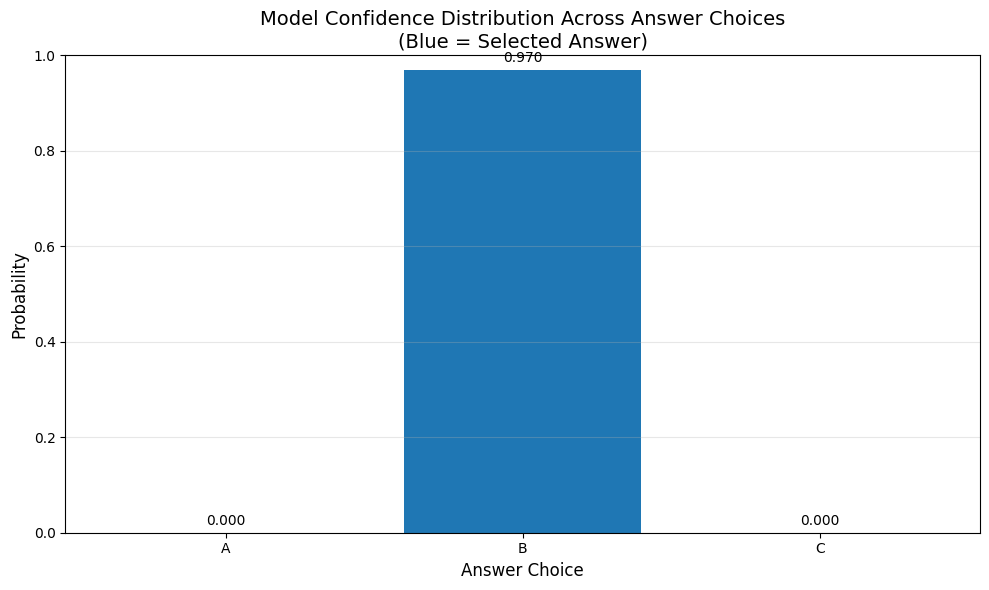


Predicted Answer: B
Confidence: 0.9696


In [5]:
# Extract probabilities for visualization
if answer_choices and len(answer_choices) > 0:
    choices = sorted(answer_choices.keys())
    probs = [answer_choices[c]['probability'] for c in choices]
    
    plt.figure(figsize=(10, 6))
    colors = ['#1f77b4' if c == result['generated_text'].strip() else '#7f7f7f' 
              for c in choices]
    
    plt.bar(choices, probs, color=colors)
    plt.xlabel('Answer Choice', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.title('Model Confidence Distribution Across Answer Choices\n(Blue = Selected Answer)', fontsize=14)
    
    # Set y-axis limit based on max probability
    if max(probs) > 0:
        plt.ylim([0, min(max(probs) * 1.2, 1.0)])
    
    # Add probability values on top of bars
    for i, (choice, prob) in enumerate(zip(choices, probs)):
        plt.text(i, prob + 0.01, f'{prob:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    predicted_answer = result['generated_text'].strip()
    if predicted_answer in answer_choices:
        print(f"\nPredicted Answer: {predicted_answer}")
        print(f"Confidence: {answer_choices[predicted_answer]['probability']:.4f}")
    else:
        print(f"\nPredicted Answer: {predicted_answer}")
        print(f"Warning: Predicted answer not found in answer_choices dictionary")
else:
    print("No answer choices found in the top logprobs!")
    print("This might indicate an issue with token extraction.")

## 5. Batch Processing Multiple Medical Questions

Process multiple MedQA-style questions and extract answer probabilities.

In [6]:
# Define multiple test questions
test_questions = [
    {
        "question": "A 35-year-old woman presents with weight loss, heat intolerance, and palpitations. Physical exam reveals exophthalmos and diffuse goiter. What is the most likely diagnosis?",
        "options": {
            "A": "Hashimoto's thyroiditis",
            "B": "Graves' disease",
            "C": "Toxic adenoma",
            "D": "Thyroid cancer"
        },
        "correct": "B"
    },
    {
        "question": "A 50-year-old diabetic patient presents with foot ulcer and fever. X-ray shows gas in soft tissues. What is the most appropriate immediate management?",
        "options": {
            "A": "Oral antibiotics and outpatient follow-up",
            "B": "Wound debridement and IV antibiotics",
            "C": "Topical antibiotics only",
            "D": "Observation and wound care"
        },
        "correct": "B"
    },
    {
        "question": "What is the first-line treatment for essential hypertension in a patient without comorbidities?",
        "options": {
            "A": "Beta blockers",
            "B": "ACE inhibitors or thiazide diuretics",
            "C": "Calcium channel blockers",
            "D": "Alpha blockers"
        },
        "correct": "B"
    }
]

def extract_answer_probs(prompt, model):
    """Extract answer choice probabilities from a prompt."""
    result = model.get_next_token_logits(prompt, return_full_distribution=True)
    
    answer_probs = {}
    if result['top_logprobs']:
        for alt in result['top_logprobs'][0]:
            token = alt['token']
            token_stripped = token.strip()
            
            # Check if it's a single letter answer choice
            if token_stripped in ['A', 'B', 'C', 'D', 'E']:
                prob = np.exp(alt['logprob'])
                
                # Keep the highest probability for each letter (in case both "A" and " A" appear)
                if token_stripped not in answer_probs or prob > answer_probs[token_stripped]:
                    answer_probs[token_stripped] = prob
    
    predicted = result['generated_text'].strip()
    confidence = answer_probs.get(predicted, 0.0)
    
    return {
        'predicted': predicted,
        'confidence': confidence,
        'all_probs': answer_probs
    }

# Process all questions
results_batch = []

for i, q in enumerate(test_questions):
    prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=2)
    result = extract_answer_probs(prompt, model_few_shot)
    
    results_batch.append({
        'question_num': i + 1,
        'predicted': result['predicted'],
        'correct': q['correct'],
        'confidence': result['confidence'],
        'is_correct': result['predicted'] == q['correct'],
        'all_probs': result['all_probs']
    })

# Print results
print("Batch Processing Results:")
print("="*80)
for r in results_batch:
    status = "✓" if r['is_correct'] else "✗"
    print(f"\nQuestion {r['question_num']}: {status}")
    print(f"  Predicted: {r['predicted']} (confidence: {r['confidence']:.4f})")
    print(f"  Correct: {r['correct']}")
    print(f"  All probabilities: {', '.join(f'{k}:{v:.4f}' for k, v in sorted(r['all_probs'].items()))}")

# Calculate accuracy
accuracy = sum(1 for r in results_batch if r['is_correct']) / len(results_batch)
avg_confidence = np.mean([r['confidence'] for r in results_batch])

print(f"\n" + "="*80)
print(f"Overall Accuracy: {accuracy:.2%}")
print(f"Average Confidence: {avg_confidence:.4f}")

Batch Processing Results:

Question 1: ✓
  Predicted: B (confidence: 0.9302)
  Correct: B
  All probabilities: A:0.0000, B:0.9302, C:0.0000

Question 2: ✓
  Predicted: B (confidence: 0.9737)
  Correct: B
  All probabilities: B:0.9737, C:0.0000, D:0.0000

Question 3: ✓
  Predicted: B (confidence: 0.8741)
  Correct: B
  All probabilities: A:0.0000, B:0.8741, C:0.0000, D:0.0000

Overall Accuracy: 100.00%
Average Confidence: 0.9260


## 6. Compare Zero-Shot vs Few-Shot Performance

Compare how few-shot examples affect the model's answer probability distribution.

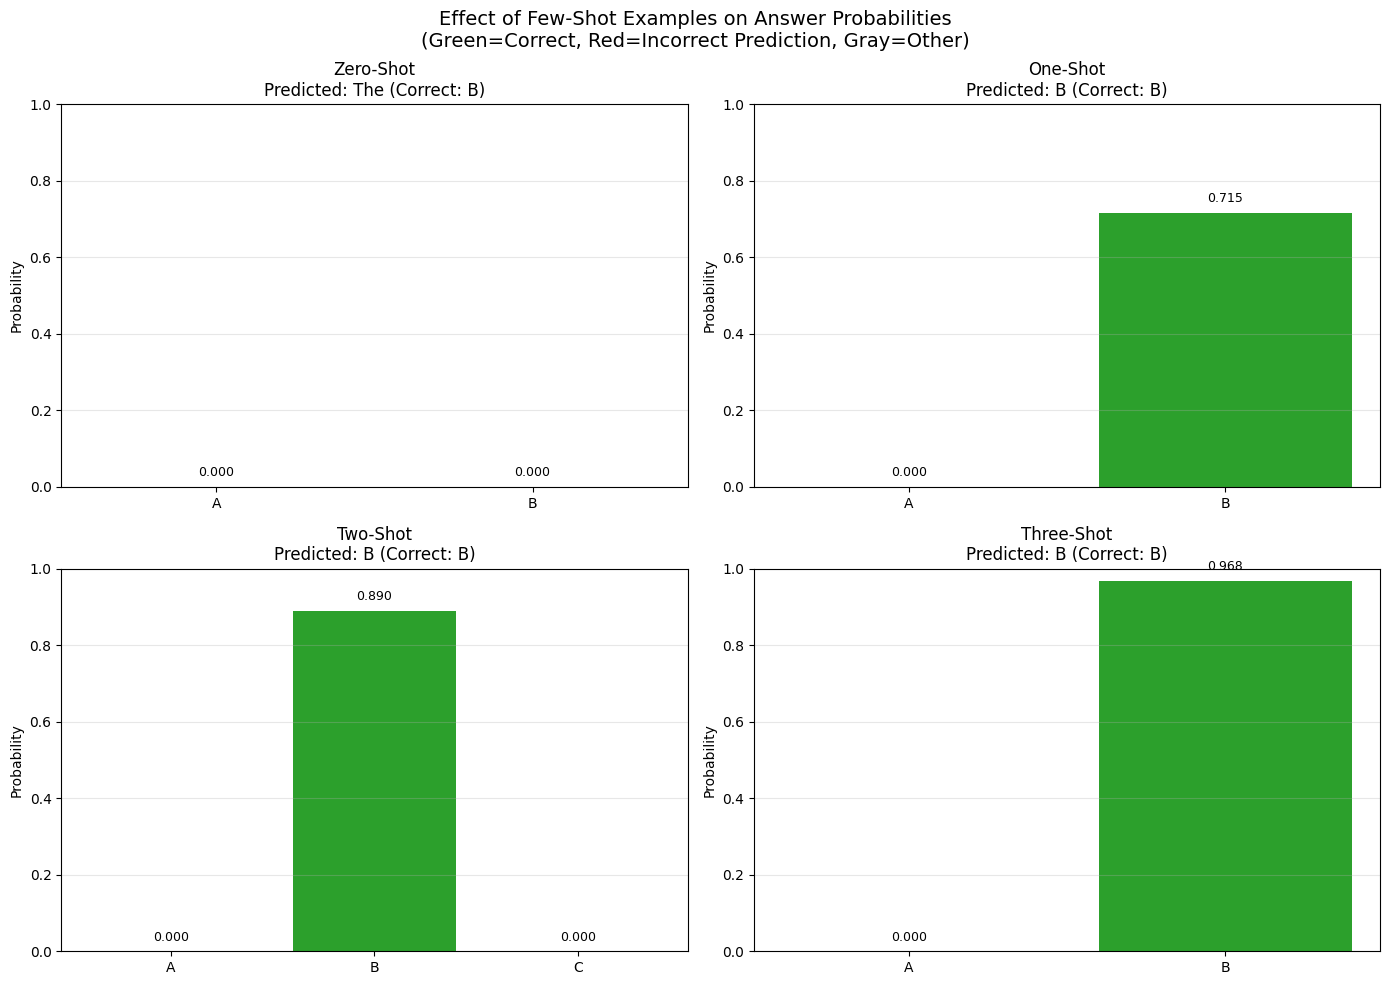


Question: A 35-year-old woman presents with weight loss, heat intolerance, and palpitations. Physical exam rev ...
Correct Answer: B

Confidence in predictions:
  Zero-Shot   : Predicted The with confidence 0.0000
  One-Shot    : Predicted B with confidence 0.7153
  Two-Shot    : Predicted B with confidence 0.8899
  Three-Shot  : Predicted B with confidence 0.9684


In [7]:
# Use the first test question
q = test_questions[0]

# Zero-shot prompt (no examples)
zero_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=0)

# Few-shot prompts with different numbers of examples
one_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=1)
two_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=2)
three_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=3)

# Extract probabilities for each
zero_shot_result = extract_answer_probs(zero_shot_prompt, model_few_shot)
one_shot_result = extract_answer_probs(one_shot_prompt, model_few_shot)
two_shot_result = extract_answer_probs(two_shot_prompt, model_few_shot)
three_shot_result = extract_answer_probs(three_shot_prompt, model_few_shot)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
results_list = [
    ('Zero-Shot', zero_shot_result),
    ('One-Shot', one_shot_result),
    ('Two-Shot', two_shot_result),
    ('Three-Shot', three_shot_result)
]

for idx, (title, result) in enumerate(results_list):
    ax = axes[idx // 2, idx % 2]
    
    choices = sorted(result['all_probs'].keys())
    probs = [result['all_probs'][c] for c in choices]
    
    colors = ['#2ca02c' if c == q['correct'] else '#d62728' if c == result['predicted'] and c != q['correct'] else '#7f7f7f' 
              for c in choices]
    
    ax.bar(choices, probs, color=colors)
    ax.set_ylabel('Probability')
    ax.set_title(f'{title}\nPredicted: {result["predicted"]} (Correct: {q["correct"]})')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add values on bars
    for i, (choice, prob) in enumerate(zip(choices, probs)):
        ax.text(i, prob + 0.02, f'{prob:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Effect of Few-Shot Examples on Answer Probabilities\n(Green=Correct, Red=Incorrect Prediction, Gray=Other)', 
             fontsize=14)
plt.tight_layout()
plt.show()

print("\nQuestion:", q['question'][:100], "...")
print(f"Correct Answer: {q['correct']}")
print("\nConfidence in predictions:")
for title, result in results_list:
    print(f"  {title:12s}: Predicted {result['predicted']} with confidence {result['confidence']:.4f}")

## 7. Uncertainty Analysis with Entropy

Calculate entropy of the answer probability distribution to measure model uncertainty.

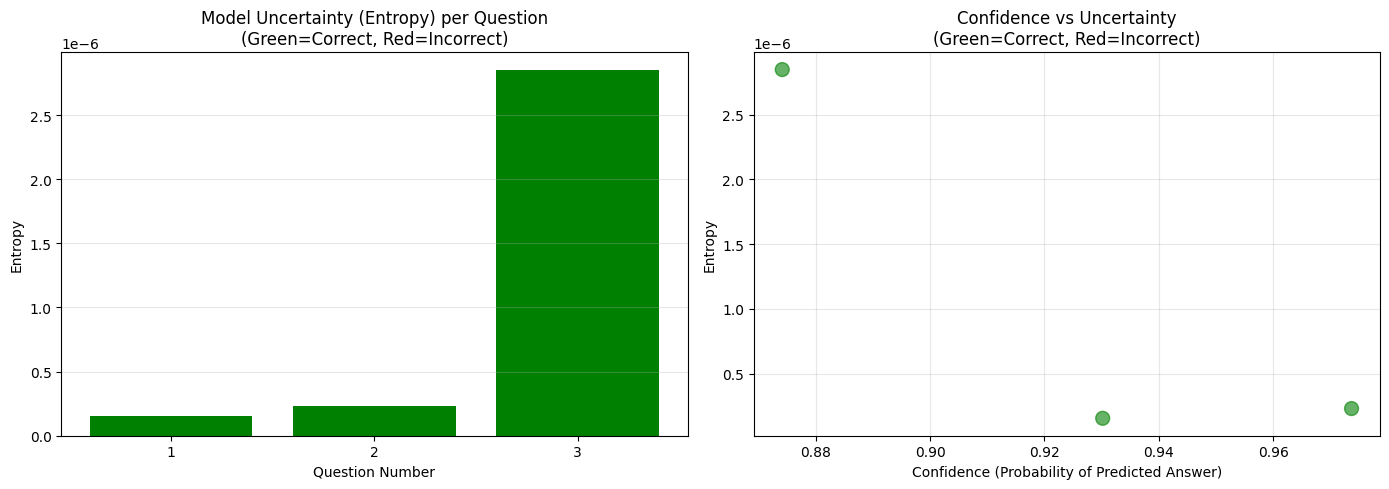

Entropy Analysis:
Question 1: ✓ | Entropy: 0.0000 | Confidence: 0.9302
Question 2: ✓ | Entropy: 0.0000 | Confidence: 0.9737
Question 3: ✓ | Entropy: 0.0000 | Confidence: 0.8741

Correlation between Confidence and Entropy: -0.8890
(Negative correlation expected: higher confidence → lower entropy)


In [8]:
def calculate_entropy(probs_dict):
    """Calculate entropy of probability distribution."""
    probs = np.array(list(probs_dict.values()))
    # Normalize to ensure sum = 1
    probs = probs / probs.sum()
    # Calculate entropy: -sum(p * log(p))
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    return entropy

# Calculate entropy for all batch results
entropy_data = []

for i, (q, r) in enumerate(zip(test_questions, results_batch)):
    entropy = calculate_entropy(r['all_probs'])
    entropy_data.append({
        'question_num': i + 1,
        'entropy': entropy,
        'confidence': r['confidence'],
        'is_correct': r['is_correct']
    })

# Visualize entropy vs confidence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Entropy for each question
colors = ['green' if d['is_correct'] else 'red' for d in entropy_data]
ax1.bar(range(len(entropy_data)), [d['entropy'] for d in entropy_data], color=colors)
ax1.set_xlabel('Question Number')
ax1.set_ylabel('Entropy')
ax1.set_title('Model Uncertainty (Entropy) per Question\n(Green=Correct, Red=Incorrect)')
ax1.set_xticks(range(len(entropy_data)))
ax1.set_xticklabels([d['question_num'] for d in entropy_data])
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Scatter of Confidence vs Entropy
confidences = [d['confidence'] for d in entropy_data]
entropies = [d['entropy'] for d in entropy_data]
ax2.scatter(confidences, entropies, c=colors, s=100, alpha=0.6)
ax2.set_xlabel('Confidence (Probability of Predicted Answer)')
ax2.set_ylabel('Entropy')
ax2.set_title('Confidence vs Uncertainty\n(Green=Correct, Red=Incorrect)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Entropy Analysis:")
print("="*80)
for d in entropy_data:
    status = "✓" if d['is_correct'] else "✗"
    print(f"Question {d['question_num']}: {status} | Entropy: {d['entropy']:.4f} | Confidence: {d['confidence']:.4f}")

# Calculate correlation
correlation = np.corrcoef(confidences, entropies)[0, 1]
print(f"\nCorrelation between Confidence and Entropy: {correlation:.4f}")
print("(Negative correlation expected: higher confidence → lower entropy)")

## 8. Integration with MCal Framework

Format the output to be compatible with MCal calibration analysis.

In [9]:
def get_mcal_compatible_probabilities(questions_data, model, num_examples=2):
    """
    Get probabilities in MCal-compatible format.
    
    Returns:
        predictions: numpy array of shape (n_samples, n_classes) with probability distributions
        labels: numpy array of shape (n_samples,) with correct answer indices
    """
    predictions = []
    labels = []
    
    letter_to_idx = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
    
    for q in questions_data:
        # Create prompt
        prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=num_examples)
        
        # Get probabilities
        result = extract_answer_probs(prompt, model)
        
        # Convert to array format [P(A), P(B), P(C), P(D), P(E)]
        num_options = len(q['options'])
        prob_array = np.zeros(num_options)
        
        for choice, prob in result['all_probs'].items():
            idx = letter_to_idx[choice]
            if idx < num_options:
                prob_array[idx] = prob
        
        # Normalize to ensure sum = 1
        if prob_array.sum() > 0:
            prob_array = prob_array / prob_array.sum()
        else:
            # Uniform distribution fallback
            prob_array = np.ones(num_options) / num_options
        
        predictions.append(prob_array)
        labels.append(letter_to_idx[q['correct']])
    
    return np.array(predictions), np.array(labels)

# Get MCal-compatible format
predictions, labels = get_mcal_compatible_probabilities(test_questions, model_few_shot, num_examples=2)

print("MCal-Compatible Output:")
print("="*80)
print(f"Predictions shape: {predictions.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nPredictions (probability distributions):")
print(predictions)
print(f"\nLabels (correct answer indices):")
print(labels)

# Calculate accuracy
predicted_labels = np.argmax(predictions, axis=1)
accuracy = np.mean(predicted_labels == labels)
print(f"\nAccuracy: {accuracy:.2%}")

# Calculate expected calibration error (ECE)
def calculate_ece(predictions, labels, n_bins=10):
    """Calculate Expected Calibration Error."""
    confidences = np.max(predictions, axis=1)
    predicted_labels = np.argmax(predictions, axis=1)
    accuracies = (predicted_labels == labels).astype(float)
    
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_mask = (confidences >= bins[i]) & (confidences < bins[i + 1])
        if bin_mask.sum() > 0:
            bin_confidence = confidences[bin_mask].mean()
            bin_accuracy = accuracies[bin_mask].mean()
            ece += (bin_mask.sum() / len(labels)) * abs(bin_confidence - bin_accuracy)
    
    return ece

ece = calculate_ece(predictions, labels)
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print("\n(Lower ECE indicates better calibration)")

MCal-Compatible Output:
Predictions shape: (3, 4)
Labels shape: (3,)

Predictions (probability distributions):
[[4.36346235e-09 9.99999993e-01 2.64657370e-09 0.00000000e+00]
 [0.00000000e+00 9.99999990e-01 7.19413603e-09 2.99896207e-09]
 [7.73441956e-08 9.99999815e-01 9.93119129e-08 8.15201824e-09]]

Labels (correct answer indices):
[1 1 1]

Accuracy: 100.00%
Expected Calibration Error (ECE): 0.0000

(Lower ECE indicates better calibration)


## Summary

This notebook demonstrated:

1. **Basic model initialization** with OpenAI API
2. **Few-shot prompting for medical MCQs** following MedQA/MedMCQA format
3. **Extracting answer choice probabilities** from next-token logits
4. **Visualizing probability distributions** across answer choices
5. **Batch processing** multiple questions
6. **Comparing zero-shot vs few-shot** performance
7. **Uncertainty analysis** using entropy
8. **MCal-compatible output format** for calibration analysis

Key findings:
- Few-shot examples improve model's adherence to single-character answer format
- Lower temperature (0.3) produces more deterministic, confident predictions
- Entropy serves as a useful uncertainty measure (inversely correlated with confidence)
- Output format is compatible with MCal calibration framework

This approach enables:
- **Model calibration** research on API-based models
- **Uncertainty quantification** for medical QA tasks
- **Comparison** between local and API-based models
- **Integration** with existing MCal workflows